# 목적
- AI Workflow가 무엇인지 이해합니다.
- LangGraph 수업을 위한 세팅을 합니다.
- LangGraph 기본 코드를 이해해봅니다.

# 1. AI Workflow

AI Workflow 라는 툴 들어보셨을까요!?

 - 코딩없이 자동화 프로그램을 만드는 "노코드" 프로그램들이 있습니다.
 - 아래 그림처럼 마우스로 배치하고, 연결하면 하나의 자동화프로그램이 완성됩니다.


아래 그림을 보시면 됩니다.
- 참고로 아래툴은 make 라는 툴입니다. (make.com)

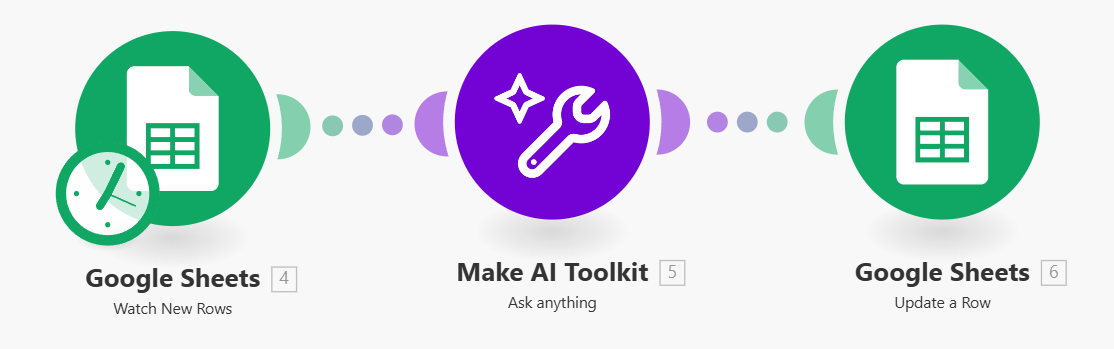

위 그림을 이렇게 해석할 수 있습니다.

1. Google Sheet의 새로운 행에 무언가 기록되면
2. LLM에게 기입한 내용이 전달되고, 사전에 세팅된 프롬프트로 LLM이 동작합니다.
3. LLM 이 만든 문장을 다시 Google Sheet에 적습니다.

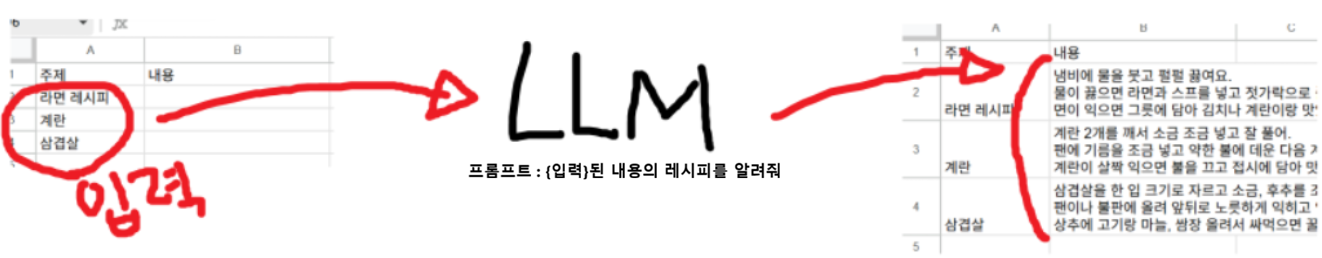

입력 데이터가, 어디를 거치고, 또 어디를 거치고, AI도 거치고 하여, 출력을 내는 것 까지~~~

이러한 데이터 처리 Flow를 만드는 것을 AI Workflow 라고 합니다.

중요합니다. 암기해주세요 "AI Workflow" : LLM가 포함되어 있는 작업 흐름 입니다.

사무업무 자동화 툴로, 사무직 분들에게 인기가 많아요.
- 반복적인 엑셀작업을 AI가 자동으로 초안을 작성하게 만들 수 있어요.
- 영수증을 업로드하면 엑셀에 날짜, 시간, 가격 등 촥촥촥 정리되는 툴을 만들 수 있어요.
- 긴급한 메일이 오면, AI가 내용을 요약하여 내 개인 SNS로 전송되게 만들 수 있어요.

아래는 Workflow를 해석해봅시다.

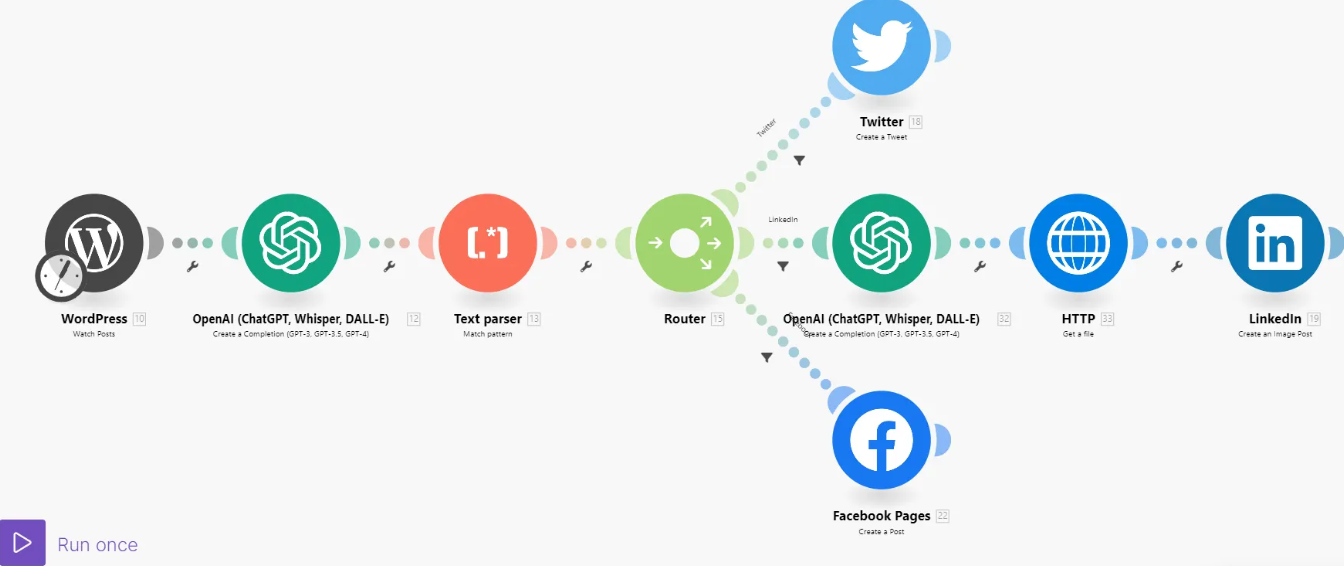

1. 뉴스에 신규 기사가 뜨자마자
2. OpenAI - LLM으로 내용을 요약하고
3. 중요한 Text만 추출하고
4. 트위터, 페이스북에 내용을 전송하여 Posting 하고
5. OpenAI - LLM이 요약된 내용을 기반으로 관련 그림을 만들어서 링크드인에 이미지와 글을 포스팅한다.


1. 뉴스에 신규 기사가 뜨자마자
2. 내용을 요약하고
3. 중요한 Text만 파싱하고
4. 트위터, 페이스북에 전송하고,
5. 관련 그림을 만들어서 링크드인에 이미지와 글을 올린다.

2024년에는 Youtube에 이런 영상이 되게 많았어요.
- AI Workflow를 잘 구축해서, 자동 Shorts 생성기를 만들어서 돈을 자동으로 버는 노하우! (???)
- AI Workflow를 잘 구축해서, 블로그 자동 포스팅으로 돈을 자동으로 버는 노하우!!! (?????)

아무튼...

Workflow라는 용어는 AI에서 굉장히 자주 쓰는 용어이니, 꼭 기억해주세요.

# 2. AI Workflow를 만들기 위해서는?

- GUI로 마우스로 휙휙 연결해서 Workflow 만드는 툴이 많습니다!
- 대표적으로 OpenAI에서 밀고있는 Agent Builder 도 있고, 뭐 많습니다.
    - make, flowise, n8n, lindy, Langflow 등등 많습니다.
 
- 약간의 개발 지식만으로 마우스 연결을 통해 Workflow를 만들 수 있습니다.


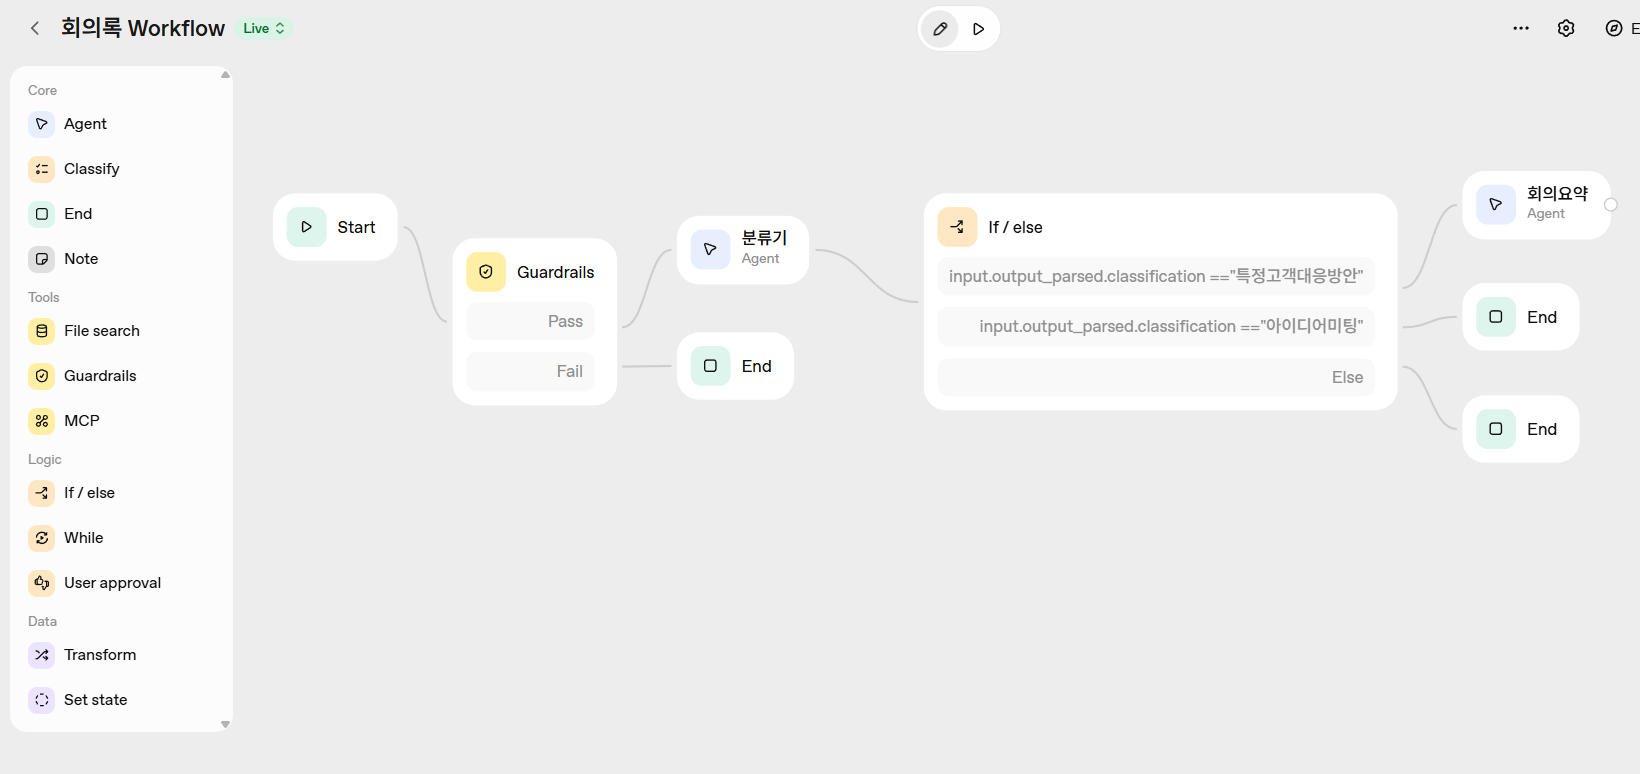

수 많은 Workflow Tool 중에서 왕은 누구냐?
- n8n : (발음 : 엔-에잇-엔) 업무자동화의 왕
- ComfyUI : (발음 : 컴피유아이) 이미지 생성도구의 왕

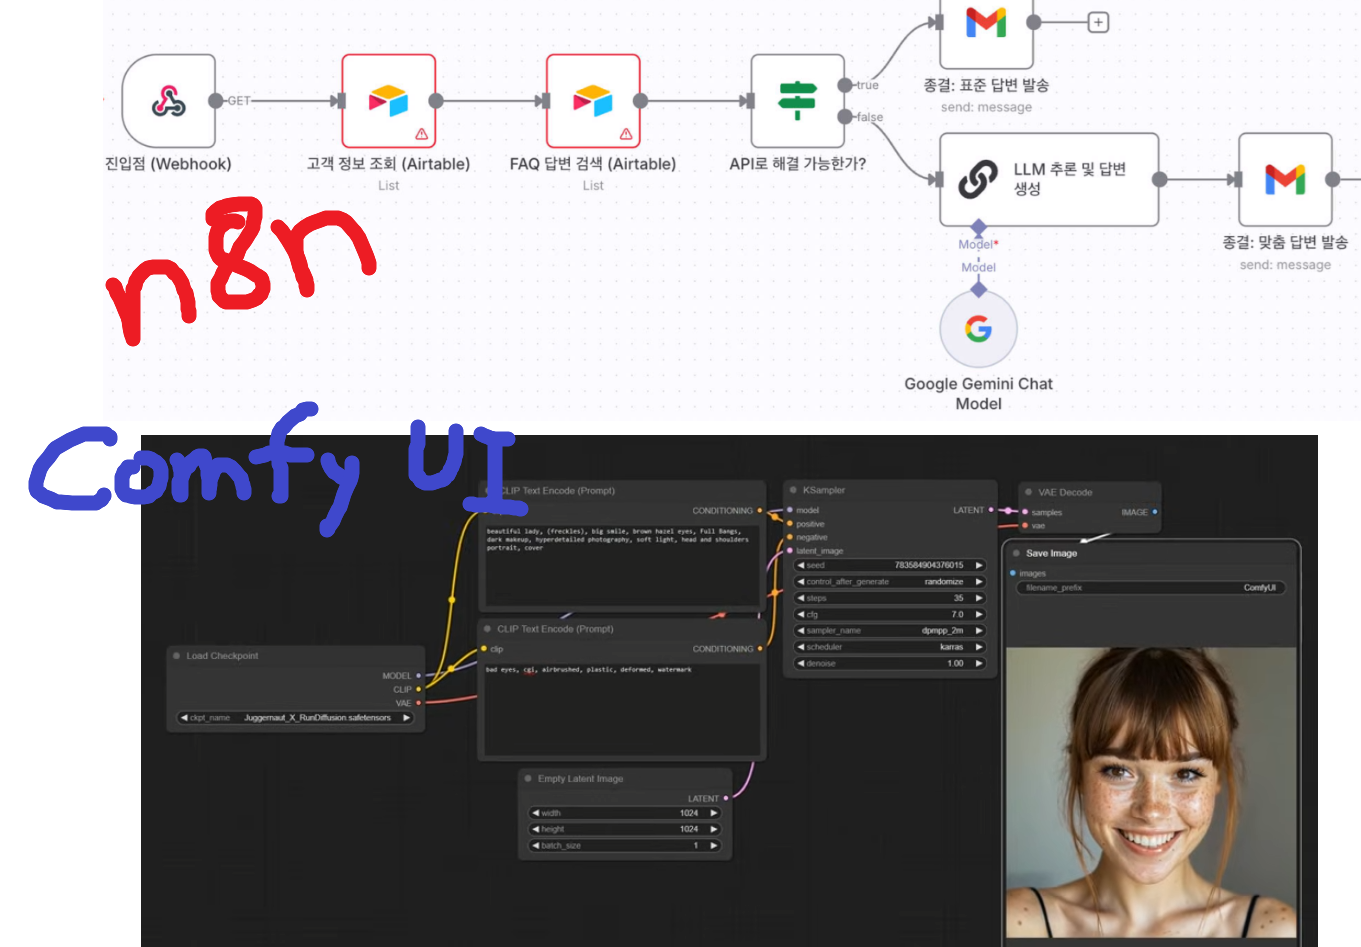

그럼 실제 개발 기업에서 AI Workflow가 필요할 때 무엇을 사용할까요?

GUI 기반 도구보다는 Python 코드로 직접 Workflow를 구성하는 경우가 많습니다.

이때 Python으로 AI Workflow를 구현할 수 있는 프레임워크 인 "LangGraph(랭그래프)" 가 많이 쓰입니다.

# 3. 실습 준비

### 키 보관을 위한 .env 파일 준비
- 키를 입력하고자 합니다.
- 안전하게 키를 관리하기 위해 .env 파일을 생성할겁니다.
- .env파일은 숨김파일이므로, 먼저 쥬피터랩에서 숨김파일이 보이도록 세팅해줍니다.

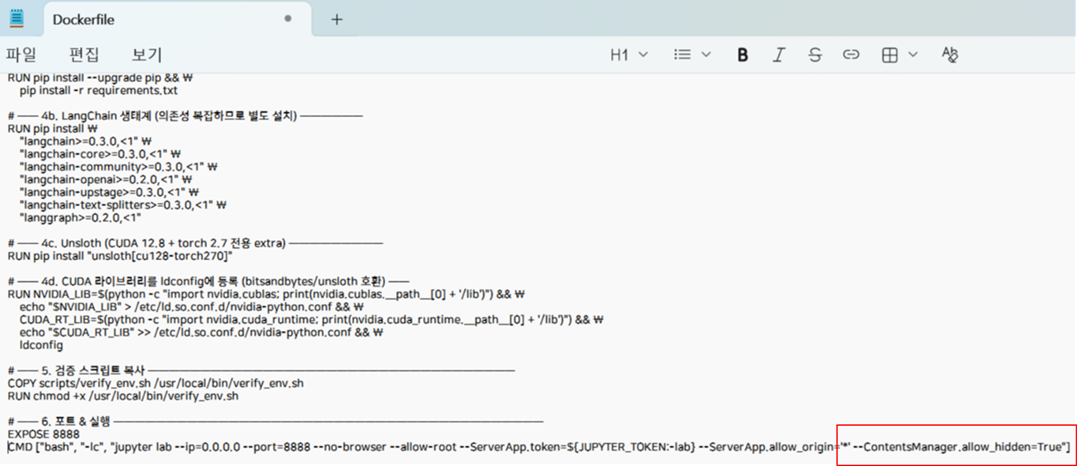

```
CMD ["bash", "-lc", "jupyter lab --ip=0.0.0.0 --port=8888 --no-browser --allow-root --ServerApp.token=${JUPYTER_TOKEN:-lab} --ServerApp.allow_origin='*' --ContentsManager.allow_hidden=True"]
```

이제 숨김파일이 보이도록 세팅합니다.

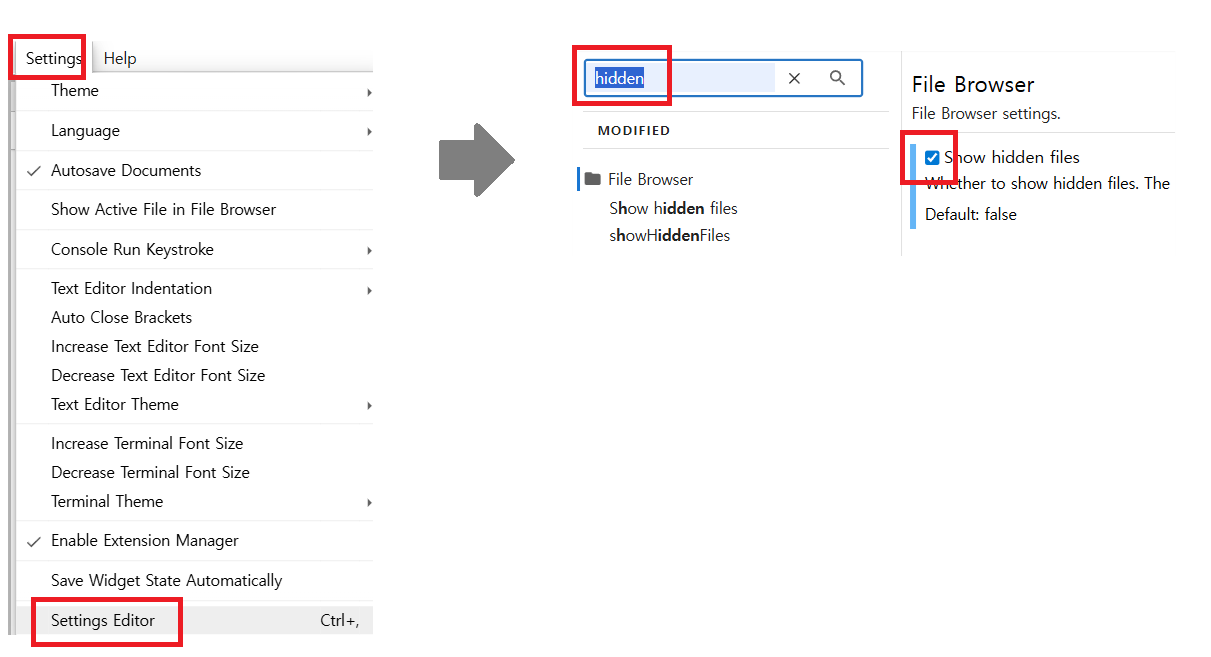

이제 .env 파일을 하나 생성합니다.

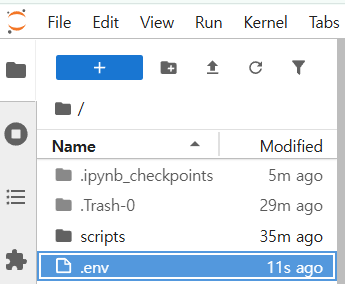

### Upstage API 키 테스트

.env 파일에 키 정보를 입력합니다.

```
UPSTAGE_API_KEY=[API KEY]
```

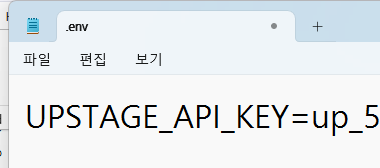

아래 코드를 실행하면 .env 에 있는 키 들이 OS에 세팅됩니다.

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

Upstage API키를 테스트해봅시다.

In [2]:
# TODO 1: LLM에게 직접 질문하기
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage

# Solar 대안 (주석 해제하여 사용)
from langchain_upstage import ChatUpstage
llm = ChatUpstage(model="solar-pro3")

question = "KFC 버거 추천좀 해줘, 두줄 요약"

# LLM에게 직접 질문
response = llm.invoke([HumanMessage(content=question)])

print("📝 질문:", question)
print("\n🤖 LLM 응답:")
print(response.content)

📝 질문: KFC 버거 추천좀 해줘, 두줄 요약

🤖 LLM 응답:
1. **클래식 버거**: 바삭한 치킨 패티와 특제 양념, 상큼한 피클·양상추가 어우러진 기본 메뉴로, KFC의 맛을 가장 깔끔하게 느끼고 싶을 때 추천합니다.  
2. **핫 허브 버거**: 매운 허브 양념과 치즈가 추가된 변형 메뉴로, 치킨의 고소함과 매운맛이 동시에 끌리는 사람에게 딱 맞습니다.


# 4. 랭그래프 체험하기

랭그래프 수업을 하기 전이지만, 아래 코드를 테스트삼아 실행해봅시다.

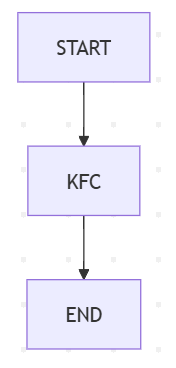

In [3]:
from langgraph.graph import StateGraph, MessagesState, START, END

def kfc(state: MessagesState):
    return {"messages": [{"role": "ai", "content": "hello world"}]}

graph = StateGraph(MessagesState)
graph.add_node("KFC", kfc) # KFC 노드를 만든다.
graph.add_edge(START, "KFC") # START 노드랑 KFC 노드랑 연결하기
graph.add_edge("KFC", END) # KFC 노드랑 END 노드랑 연결하기

agent = graph.compile() #빌드

result = agent.invoke({"messages": [{"role": "user", "content": "hi!"}]}) #실행

# 이쁘게 콘솔 로그 출력
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

hi!
================================== Ai Message ==================================

hello world


잘 됩니다!
- 위 Hello World 코드를 자세히 이해하는 건 나중으로 미루겠습니다.

<br/>

일단 이제 용어를 암기할 시간입니다.

1. 랭그래프에서는 AI Workflow를 "**Agent**" 라고 부릅니다.
2. 랭그래프에서 Workflow(Agent)를 구성하고 있는 각 단계를 "**Node**" 라고 합니다.
3. 랭그래프에서 Node끼리 연결선을 **Edge** 라고 합니다.
4. 랭그래프에서 Node가 값을 저장할 수 있는 공간을 **State** 라고 합니다.

<br/>

지금 외워주세요!

Agent, Node, Edge, State

다음 코드를 한번 이해해보세요. 
- 이 코드는 랭그래프의 기본 구조입니다! 흐름을 가볍게 이해해주세요.
- 디테일한 내용은 하나씩 배워갈겁니다.

In [4]:
from langgraph.graph import StateGraph, START, END

# 1. 노드 함수 정의
def kfc(state):
    print("KFC 실행")
    return {"result": "kfc 실행"}

def bbq(state):
    print("BBQ 실행")
    return {"result": state["result"] + " -> bbq 실행"}

# 2. 그래프 생성
graph = StateGraph(dict)

# 3. 그래프에 노드 추가
graph.add_node("KFC", kfc)
graph.add_node("BBQ", bbq)

# 4. 엣지 연결
graph.add_edge(START, "KFC")
graph.add_edge("KFC", "BBQ")
graph.add_edge("BBQ", END)

# 5. 컴파일
agent = graph.compile()

# 6. 실행
result = agent.invoke({})

print("\n최종 결과:", result)

KFC 실행
BBQ 실행

최종 결과: {'result': 'kfc 실행 -> bbq 실행'}


여기까지 잘 따라와주셨습니다.

이제 랭그래프를 더 심도있게 다루기 전, 

학습에 도움이 되는 툴인 "**LangSmith(랭스미스)**" 세팅을 해볼겁니다.

웹 개발할때 "개발자도구"를 사용할 수 있도록 세팅하는 것으로 비유할 수 있겠습니다!
 

---

# 5. LangSmith (랭스미스) 세팅 및 체험하기

랭스미스는 꼭 랭그래프가 아니더라도, OpenAI API를 쓰거나 진행상황을 추적 (Tracing)을 할수 있습니다.
- 랭스미스는 "LLM 실행 결과를 모니터링 / 분석" 할때 쓰이는 Web 기반 도구입니다.

랭그래프가 동작되는 상태를 보려면 이 "랭스미스"가 필요합니다.

Q. 랭스미스 안쓰고, 랭그래프만 쓰면 안되나요?
- 랭그래프만 써도 되는데요, 그런데 랭스미스를 쓰면 중간 진행 상황들을 다 볼 수 있어요.
- 우리 수업에서는 랭그래프를 동작시키고, 결과를 랭스미스로 이쁜 그래프 그림과 함께 이해해보고자 쓰는겁니다.
- 게다가 랭그래프가 잘 동작안되면, 이걸로 원인분석 (디버깅)도 가능합니다!

Q. 많이 쓰나요?
- 랭그래프로 개발하려면 무조건 써야합니다. 무조건!
- 웹개발할때 개발자도구로 비유할수있어요.

### 랭스미스 세팅

3개를 해야합니다.
1. 랭스미스 가입 (구글 계정으로도 가입 됩니다.)
2. 랭스미스 KEY 발급
3. 랭스미스 KEY를 .env 파일에 넣기

일단 가입 후 로그인합시다.
- https://smith.langchain.com/

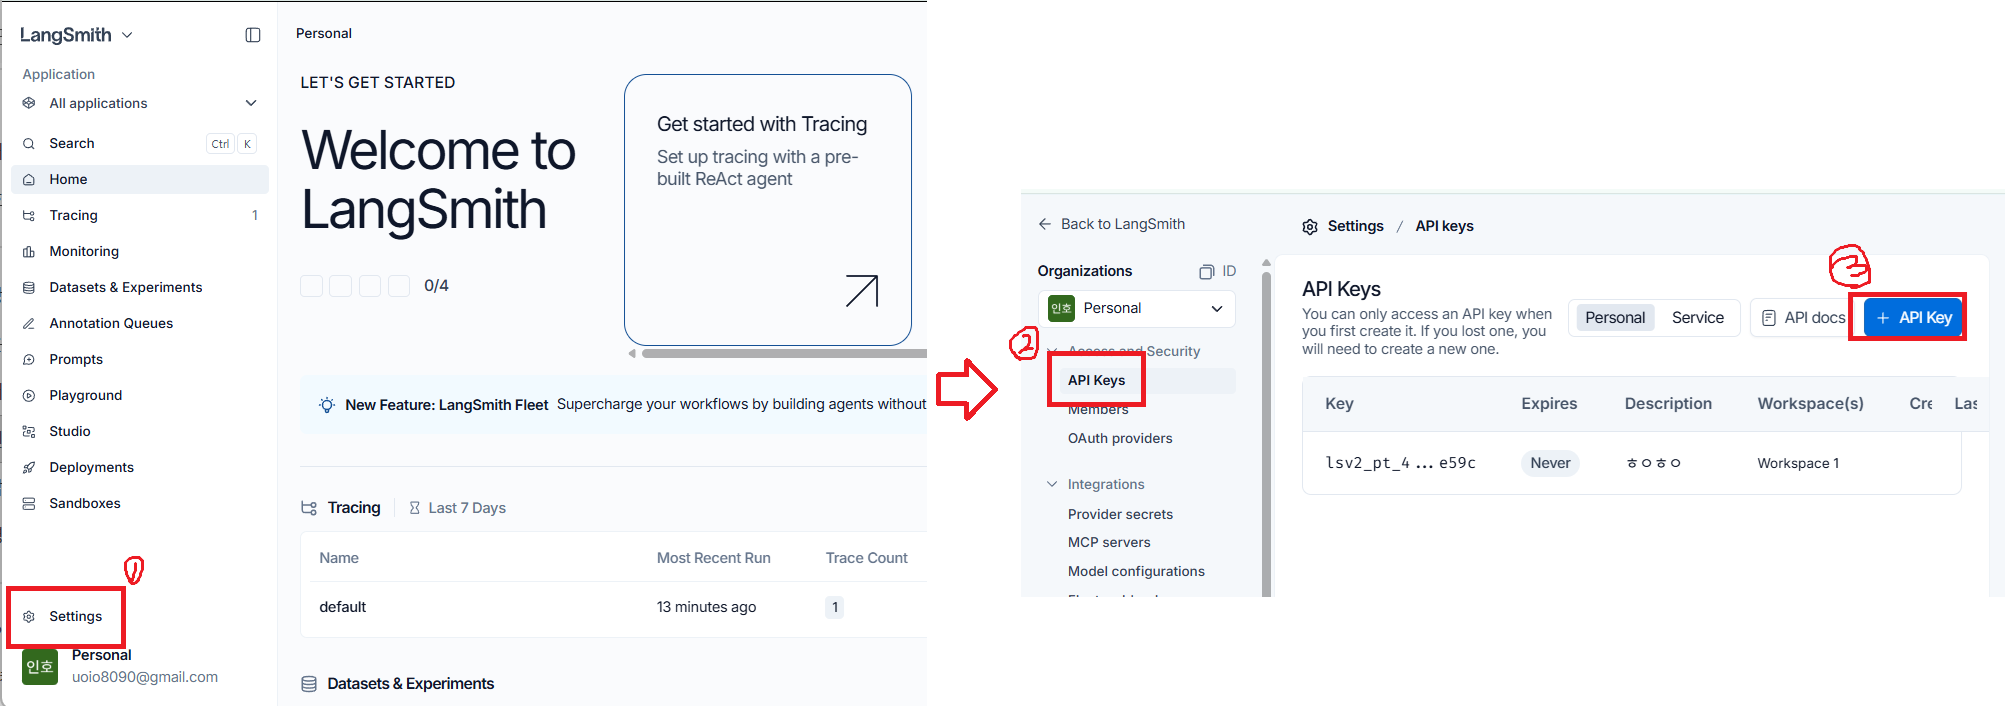

키를 하나 생성합니다. 

이미 익숙하시겠지만, KFC라고 적은 것은 아무이름이나 해도 상관없다는 의미입니다.

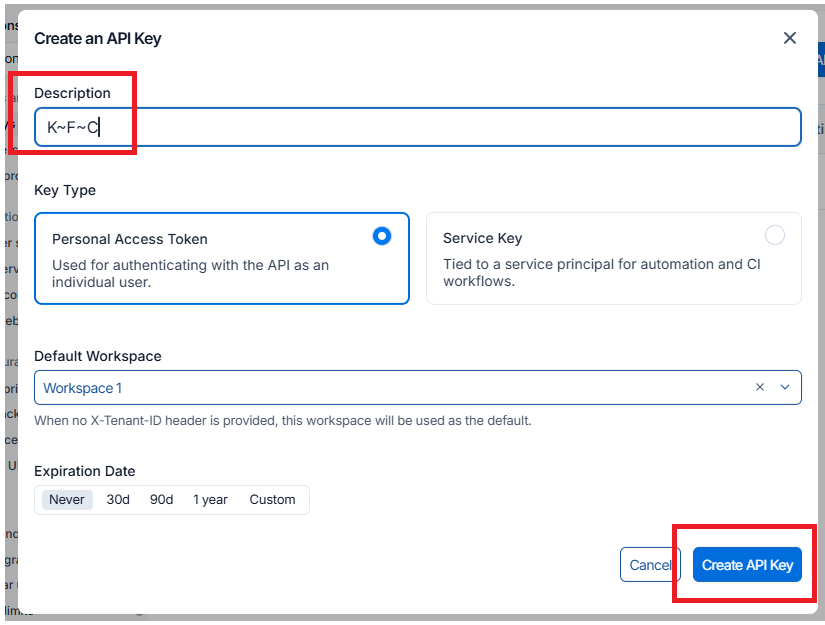

이제 키가 생겼으니, .env파일에 잘 적어줘야합니다.

```
UPSTAGE_API_KEY=[API KEY]
LANGSMITH_TRACING=true
LANGSMITH_API_KEY=lsv...
```

아래 코드를 실행시켜 .env파일 내용을 OS에 등록시켜줍니다.

In [5]:
from dotenv import load_dotenv

load_dotenv()

True

### LangSmith - Tracing

랭스미스가 잘 동작되는지 확인해보려고 합니다.

아래 코드를 실행해봅시다.
- OpenAI 의 Wrapper를 넣어줍니다.
- Upstage API는 OpenAI에서 엔드포인트만 다릅니다.

In [6]:
from openai import OpenAI
from langsmith.wrappers import wrap_openai  # traces openai calls
import os

# 2. Upstage용 클라이언트 설정
# base_url을 업스테이지 주소로 지정하면 OpenAI 라이브러리를 그대로 쓸 수 있습니다.
client = wrap_openai(OpenAI(
    api_key=os.environ.get("UPSTAGE_API_KEY"),
    base_url="https://api.upstage.ai/v1/solar"
))

#client = wrap_openai(OpenAI()) #여기 기존코드에 랩핑코드 추가함
# 3. 모델 설정 (업스테이지 모델명으로 변경)
model = "solar-pro" # 또는 "solar-mini"

prompt="KFC 버거 추천좀 해줘, 한줄 요약"

# 4. API 호출 (OpenAI 라이브러리 방식 그대로 유지)
# 참고: Upstage는 standard chat completion 형식을 따르므로 
# client.chat.completions.create를 사용하는 것이 일반적입니다.
response = client.chat.completions.create(
    model=model,
    messages=[{"role": "user", "content": prompt}]
)

print(response.choices[0].message.content)

**"KFC 버거 추천: '핫크리스피 버거' (바삭한 치킨 패티와 치즈의 조합, 가성비 좋음)"**  

간결한 한줄 요약입니다! 😊


랭스미스 사이트 > Tracing > default 를 누르면, 실행결과를 확인할 수 있습니다.

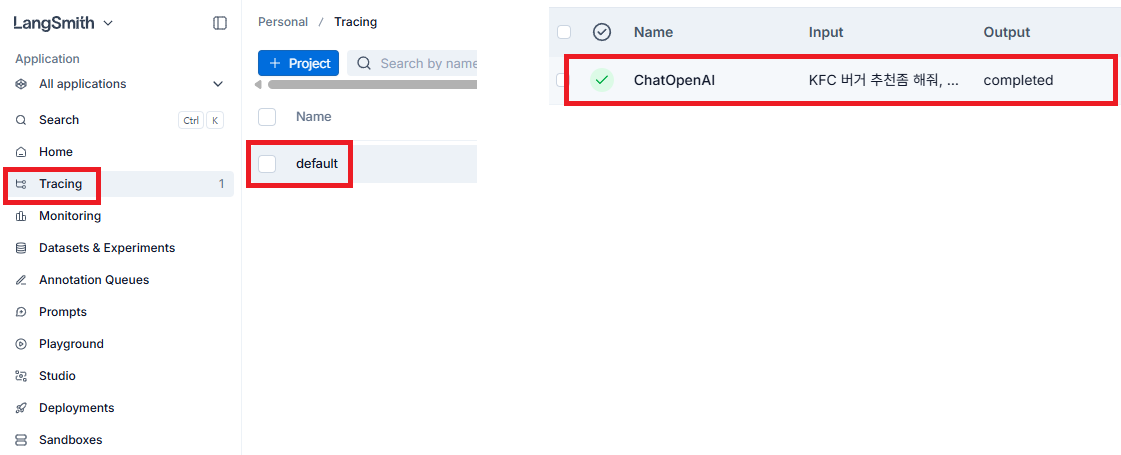

### 랭그래프 샘플코드

다시 등장한 랭그래프의 Hello World 코드입니다.

한번 실행한 후에 랭스미스에서 어떻게 보여지는지 확인해봅시다.

In [7]:
from langgraph.graph import StateGraph, MessagesState, START, END

def kfc(state: MessagesState):
    return {"messages": [{"role": "ai", "content": "hello world"}]}

graph = StateGraph(MessagesState)
graph.add_node("KFC", kfc) # KFC 노드를 만든다.
graph.add_edge(START, "KFC") # START 노드랑 KFC 노드랑 연결하기
graph.add_edge("KFC", END) # KFC 노드랑 END 노드랑 연결하기

agent = graph.compile() #빌드

result = agent.invoke({"messages": [{"role": "user", "content": "hi!"}]}) #실행

# 이쁘게 콘솔 로그 출력
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

hi!
================================== Ai Message ==================================

hello world


---

아래 코드는 Upstage API를 사용하여 챗봇 코드를 만들었습니다.

구조는 다음과 같으며, 한번 실행해봅시다.

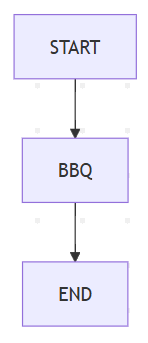

In [8]:
import os
from typing import Annotated, TypedDict, List
import operator
from dotenv import load_dotenv

# LangGraph 0.2 및 관련 라이브러리 경로 준수
from langchain_upstage import ChatUpstage  # 직접 임포트
from langchain_core.messages import AnyMessage, HumanMessage
from langgraph.graph import StateGraph, START, END

# 1. 환경 변수 로드
load_dotenv()

# 2. 모델 설정 (ChatUpstage 직접 선언)
# 0.2 버전 환경에서는 init_chat_model보다 이 방식이 훨씬 정확하게 동작합니다.
model = ChatUpstage(
    model="solar-pro", 
    # upstage_api_key=os.getenv("UPSTAGE_API_KEY"), # 필요시 명시적 지정
    temperature=0
)

# 3. LangGraph State 정의
class State(TypedDict):
    # Annotated와 operator.add를 사용하여 메시지가 계속 쌓이도록 설정
    messages: Annotated[List[AnyMessage], operator.add]

# 4. 노드 정의
def BBQ(state: State):
    # 모델 호출 시 현재까지의 모든 메시지 기록을 전달
    response = model.invoke(state["messages"])
    # 0.2 버전에서도 리스트 형태로 반환하여 메시지를 추가함
    return {"messages": [response]}

# 5. 그래프 구성
workflow = StateGraph(State)

workflow.add_node("BBQ", BBQ)

# START -> BBQ -> END 흐름 설정
workflow.add_edge(START, "BBQ")
workflow.add_edge("BBQ", END)

# 6. 컴파일
agent = workflow.compile()

# 7. 실행
input_data = {
    "messages": [HumanMessage(content="KFC랑 맥도날드 치킨 중 뭐가 더 맛있지? 한줄 요약")]
}

result = agent.invoke(input_data)

# 8. 결과 출력
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

KFC랑 맥도날드 치킨 중 뭐가 더 맛있지? 한줄 요약
================================== Ai Message ==================================

"취향 차이: KFC는 바삭하고 풍부한 맛, 맥도날드 치킨이라면 가벼운 튀김 맛이 특징."  

(한 줄 요약: 취향에 따라 KFC는 바삭함, 맥도날드는 가벼운 맛으로 갈림.)


---

실행 결과는 다음과 같습니다.

비용이 써있는데 놀라지 않아도 됩니다.

이건 단순히 "API의 비용 추정치" 입니다.

랭그래프는 교육 / 연구 / 테스트 용도로 무료 라이센스입니다. (무료 제한 : 5,000번 Trace/월)

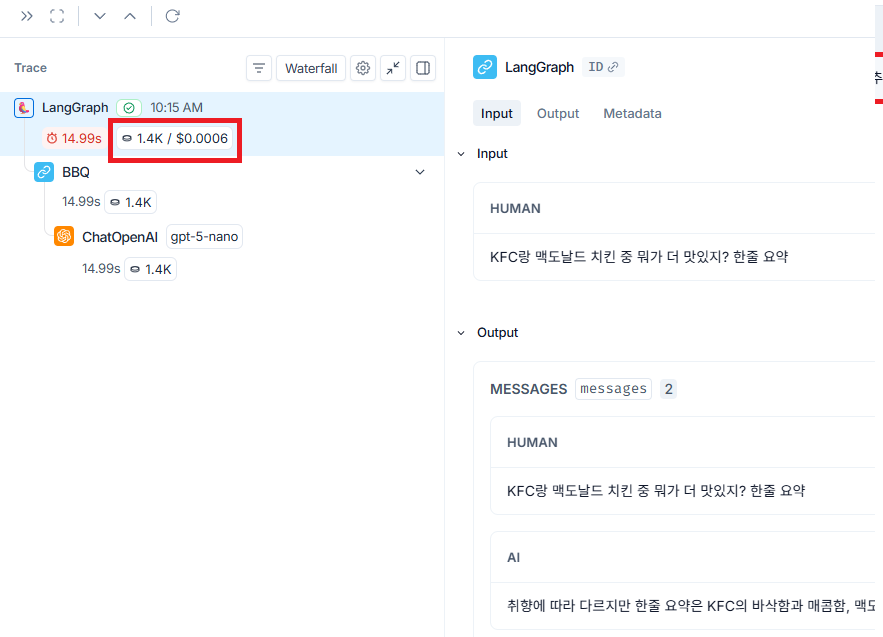

### LangSmith - Studio

랭스미스의 "스튜디오" 기능은 랭그래프가 내부적으로 동작중인 모습을 시각화하여 볼 수 있습니다.

동작 테스트를 하면서, 디버깅할 때 매우 좋습니다!

매우 좋은데!! 정말 좋은데!! 거기다가 무료인데!!! ㅠㅠ

아쉽게도 코랩 / 쥬피터랩 에서 실행이 되지 않습니다..  무조건 Local에서 실행을 해야합니다.
- 따로 서버를 실행해야해서요

이렇게 불편해도 세팅할 가치가 있습니다. 

정말 좋아요.

PyCharm을 켜 봅니다.

아래와 같이 3개 파일을 생성합니다.
1. .env
2. app.py
3. langgraph.json

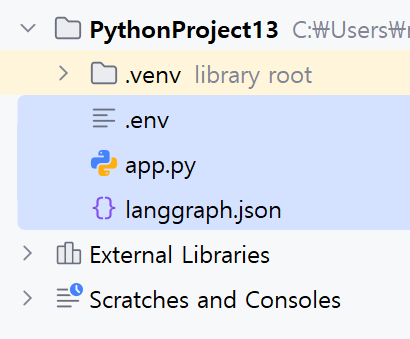


.env 파일은 기존에 세팅한 파일 내용과 동일하게 세팅합니다.

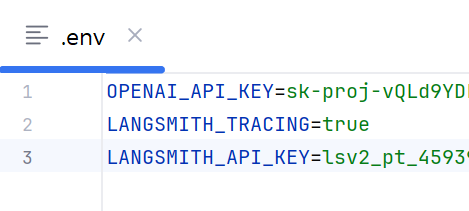

langgraph.json 파일은 아래 내용으로 기입해줍니다.

```json
{
  "dependencies": ["."],
  "graphs": {
    "agent": "./app.py:agent"
  },
  "env": ".env"
}
```

app.py 파일은 아래 내용으로 채워줍니다.

```python
import os
import operator
from typing import Annotated, TypedDict, List
from dotenv import load_dotenv

# 라이브러리 임포트 (PyCharm/LangGraph 0.2+ 호환 경로)
from langchain_upstage import ChatUpstage
from langchain_core.messages import AnyMessage, HumanMessage
from langgraph.graph import StateGraph, START, END

# 1. .env 파일 로드 (UPSTAGE_API_KEY, LANGCHAIN_API_KEY 등이 포함되어야 함)
load_dotenv()

# 2. 모델 설정 (Upstage Solar 사용)
# init_chat_model 대신 ChatUpstage를 직접 사용하면 설정이 더 간편합니다.
model = ChatUpstage(model="solar-pro", temperature=0)

# 3. LangGraph State 정의
class State(TypedDict):
    # 각 노드의 결과를 기존 리스트에 계속 추가(add)하도록 설정
    messages: Annotated[List[AnyMessage], operator.add]

# 4. 노드 정의 (BBQ 노드)
def BBQ(state: State):
    # 이전 메시지 내역을 모델에 전달하고 응답을 받음
    response = model.invoke(state["messages"])
    # 결과를 리스트에 담아 반환 (operator.add에 의해 기존 state에 합쳐짐)
    return {"messages": [response]}

# 5. 그래프 구성
workflow = StateGraph(State)

# 노드 추가
workflow.add_node("BBQ", BBQ)

# 엣지 연결 (시작 -> BBQ -> 끝)
workflow.add_edge(START, "BBQ")
workflow.add_edge("BBQ", END)

# 6. 그래프 컴파일
agent = workflow.compile()

# 7. 실행 및 결과 출력
if __name__ == "__main__":
    input_data = {
        "messages": [HumanMessage(content="KFC랑 맥도날드 치킨 중 뭐가 더 맛있지? 한줄 요약")]
    }

    print("--- 실행 시작 ---")
    result = agent.invoke(input_data)

    # 대화 기록 출력
    for m in result["messages"]:
        m.pretty_print()
```

세팅이 다 되었으므로, 이제 파이썬 패키지를 설치해줍시다.

아래 그림처럼 터미널을 엽니다.

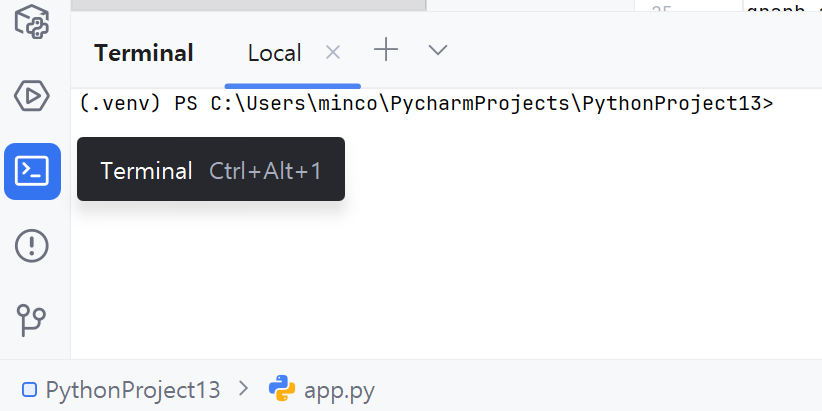

아래 명령어를 복사 붙여넣기로 설치합니다.

```shell
pip install -U "langgraph-cli[inmem]"
pip install -U langgraph langchain langsmith langchain-openai langchain-upstage
```

이제 서버를 실행합니다. 아래 명령어를 입력하세요.

```shell
langgraph dev
```

아래와 같은 메세지가 뜨면, 해당 링크로 들어가면 됩니다.
- 서버 실행도중 에러메세지가 중간에 뜰수도 있는데 무시합니다.

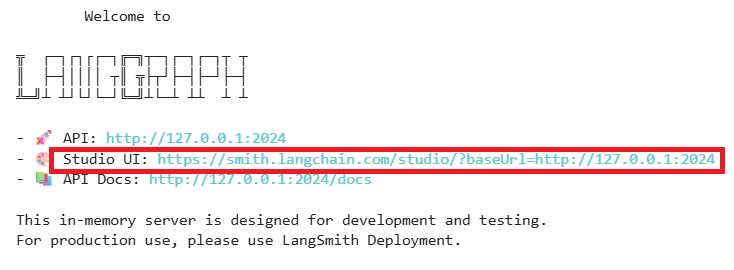

실행 결과화면은 다음과 같습니다.

Message를 눌러 챗봇이 잘 동작되는지 확인합니다.

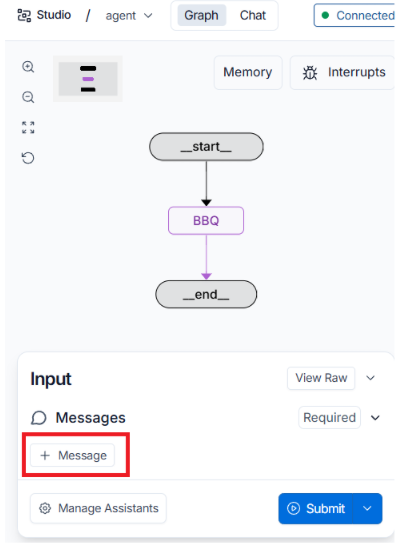

이 프로그램의 진가는 차후에 학습할 "Tool" 이라는 기능을 쓰는 것입니다.

Tool은 간단합니다.

원숭이에게 도구를 손에 쥐어주는 것 처럼.. 

LLM에게 Tool을 손에 쥐어주게 하는 것입니다.

- Tool은 함수로 구현할 수 있습니다.

랭스미스의 Studio를 통해 효율적으로 프롬프트가 잘 세팅이 되었는지, 불필요한 반복이 되고있는지 등 시각적으로 분석할 수 있습니다.
- Tool에 대해서는 차후에 자세히 배울 것입니다.
- 지금은 랭스미스의 Studio가 무엇인지 살펴봅니다.

아래 소스코드를 PyCharm에 저장후, 랭스미스 Studio에서 새로고침을 하면 됩니다.
- 아래 소스코드 역시 차후에 학습할 소스코드입니다!
- 지금은 코드를 간단히 눈으로만 살펴보고, 실행에 집중해봅시다.

```python
import os
import time
from dotenv import load_dotenv
from langchain_core.tools import tool
from langchain_upstage import ChatUpstage
# 기존 커스텀 라이브러리 임포트 (경로가 정확하다고 가정합니다)
from langchain.agents import create_agent
from langchain.agents.middleware import TodoListMiddleware

# 1. 환경 변수 로드
load_dotenv()

# 2. 검색 도구 정의
@tool(parse_docstring=True)
def internet_search(query: str) -> str:
    """인터넷 검색을 수행하는 함수 (Mock).

    Args:
        query: 검색할 키워드

    Returns:
        검색 결과 문자열
    """
    print(f"\n[로그] '{query}' 검색 중...")
    time.sleep(2) # 3초는 기니까 살짝 줄였습니다
    return f"'{query}'에 대한 검색 결과는 이렇습니다 - '제주도 코코마을 사는 인호님은 KFC를 좋아해'"

# 3. 모델 설정 및 에이전트 생성
# 만약 create_agent가 모델 객체를 직접 받을 수 있다면 아래 방식이 가장 확실합니다.
model = ChatUpstage(model="solar-pro")

agent = create_agent(
    model=model, # 'openai:gpt-5-nano' 대신 Upstage 모델 객체 전달
    tools=[internet_search],
    system_prompt="당신은 인터넷 검색을 통해 정보를 찾는 AI 어시스턴트입니다. 검색 결과를 바탕으로 답변하세요.",
    middleware=[TodoListMiddleware()],
)

# 질문 : "제주도에 코코마을이 있는데. 그 마을에 인호님이 유명하시지. 그 분이 좋아하는 선물을 추천해봐. 검색해줘"
```

한번 Message를 보내서, 잘 동작되는지 확인해주세요.

만약 동작 로그메세지가 너무 많은 경우나, 진행중인 동작을 무시하고 새로운 RUN을 해보고자 할 때 

"대화 초기화" 버튼을 눌러주시면 됩니다.

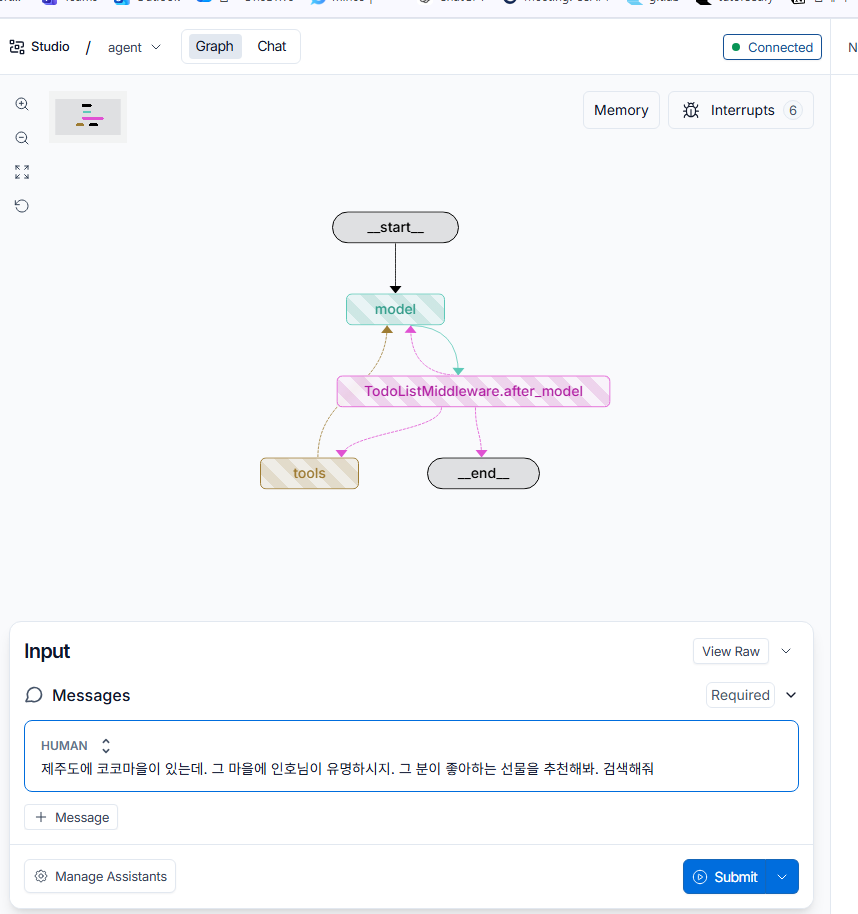

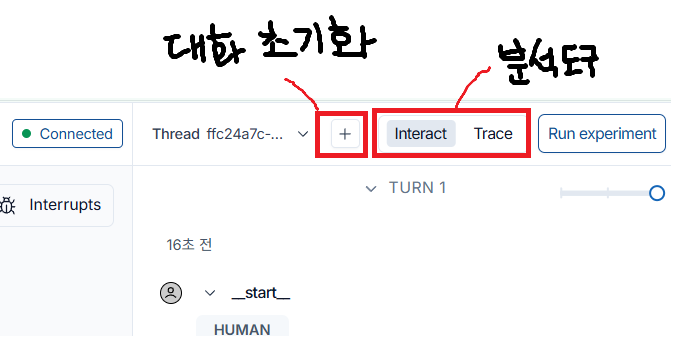

# 6. 앞으로 학습 계획

여기까지 오시느라 수고하셨습니다! 

지금까지 아래 내용을 살펴보았습니다.

- AI Workflow가 뭔지 이해하기
- LangGraph 체험해보기
- LangGrpah 수업에 사용할 툴 세팅하기

랭그래프 수업은 크게 3개 파트로 나눠 수업이 이뤄집니다.
- 1. RAG 개념을 이해하고, 랭그래프로 RAG 구현하기
- 2. 랭체인과 랭그래프 차이를 이해하고, 랭체인 Tool vs 랭그래프 Tool 비교
- 3. 자주 사용되는 대표적인 Workflow 패턴 살펴보기

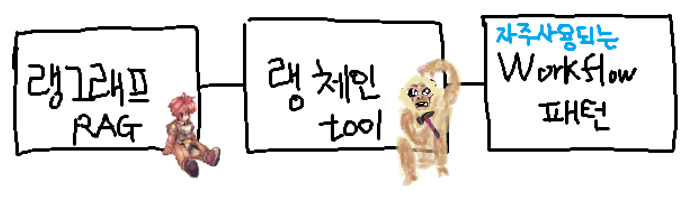